In [1]:
import pandas as pd

predictions = pd.read_csv("../out/old/unmodified/predictions.csv")
predictions.head()

,dialog_id,utterance_id,file,prediction,label,split
0,0,0,dia0_utt0.mp4,neutral,positive,output_repeated_splits_test
1,0,1,dia0_utt1.mp4,neutral,negative,output_repeated_splits_test
2,0,2,dia0_utt2.mp4,neutral,neutral,output_repeated_splits_test
3,100,0,dia100_utt0.mp4,neutral,neutral,output_repeated_splits_test
4,100,1,dia100_utt1.mp4,neutral,neutral,output_repeated_splits_test


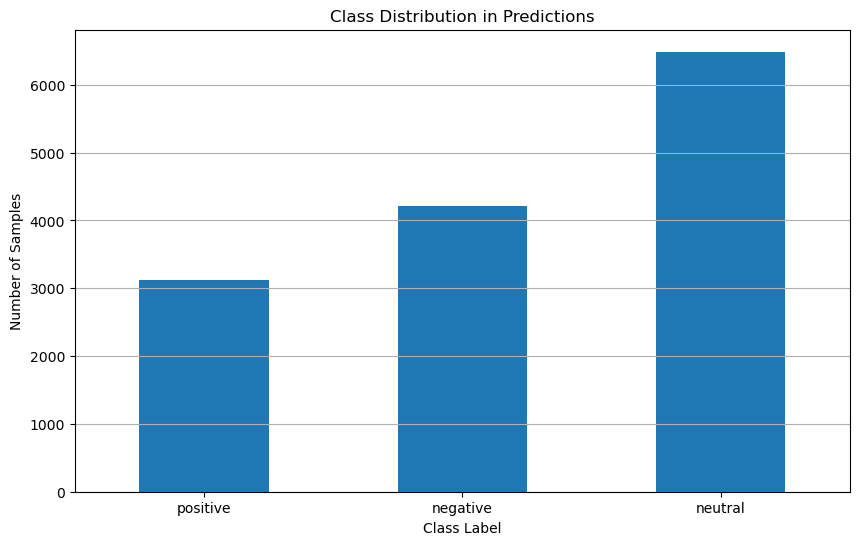

In [2]:
import matplotlib.pyplot as plt

label_counts = predictions['label'].value_counts().sort_values()
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar')
plt.title('Class Distribution in Predictions')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

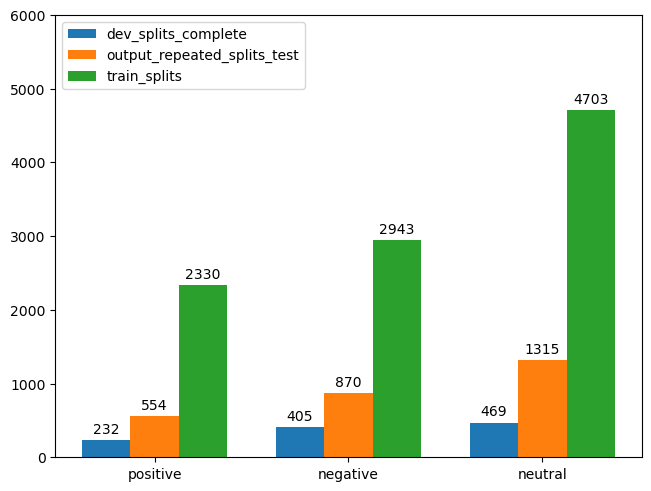

In [3]:
import numpy as np

splits = predictions['split'].unique()
splits.sort()
classes = predictions['label'].unique()
label_per_class = {}

for split in splits:
    split_data = predictions[predictions['split'] == split]
    label_counts = split_data['label'].value_counts().sort_values()
    label_per_class[split] = label_counts

x = np.arange(len(classes))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in label_per_class.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_xticks(x + width, classes)
ax.legend(loc='upper left', ncols=1)
ax.set_ylim(0, 6000)

plt.show()

In [4]:
cm_values = pd.read_csv("out/unmodified/prepared_data_all.csv")
cm_values.head()

,split,class,TP,FP,FN,TN
0,output_repeated_splits_test,positive,303,191,251,2000
1,output_repeated_splits_test,negative,347,91,523,1784
2,output_repeated_splits_test,neutral,1160,649,155,781
3,dev_splits_complete,positive,116,78,116,800
4,dev_splits_complete,negative,176,31,229,674


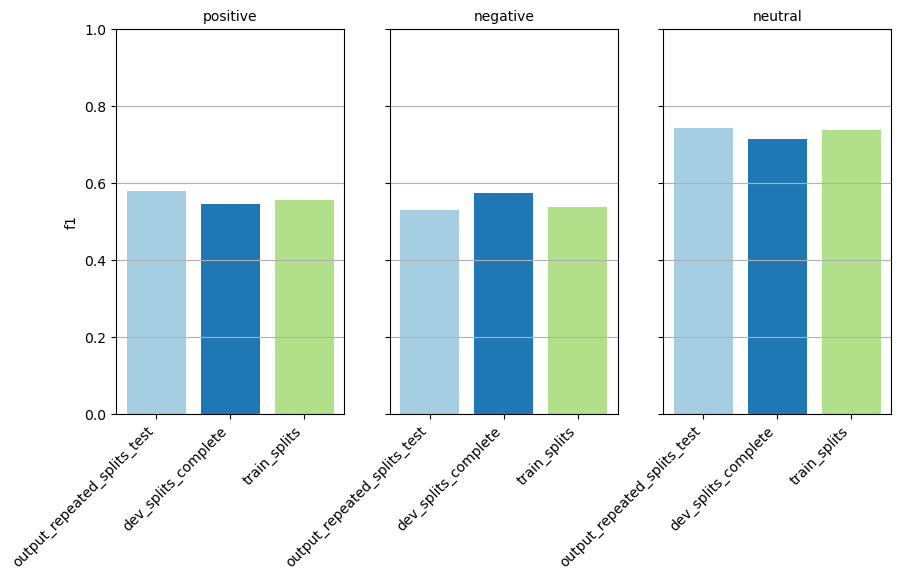

In [5]:
import os
from plotting_util import plot_metric_per_class, extract_classes

file = "prepared_data_all.csv"
modality = 'unmodified'
metric = 'f1'
out_path = os.path.join("out", metric, modality)

path = os.path.join("out", modality, file)
data: pd.DataFrame = pd.read_csv(path)

class_data = extract_classes(data)
plot_metric_per_class(class_data=class_data, modality=modality, metric=metric, out_path=out_path)

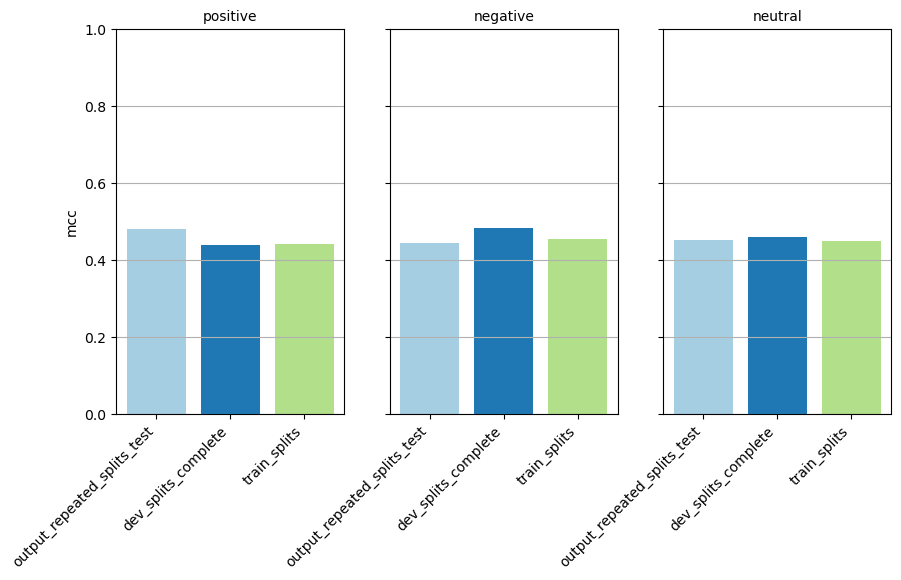

In [6]:
metric = 'mcc'
plot_metric_per_class(class_data=class_data, modality=modality, metric=metric, out_path=out_path)